# Supermarket Sales & Apple Quality: ML Case Studies

This notebook presents an end-to-end analysis of two distinct datasets, addressing three of the main categories of supervised and unsupervised Machine Learning problems.

**Datasets used:**
- **supermarket_sales** — 1,000 transactions from supermarket branches: used for regression and time series analysis.
- **apple_quality** — physical and organoleptic characteristics of 4,000 apples: used for classification and clustering.

The notebook is structured in two independent parts, one per dataset.

---

## Libraries


In [2]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

---
# Part 1 — Supermarket Sales

The `supermarket_sales` dataset contains data on 1,000 transactions carried out across three branches of a supermarket chain. The goal of this section is twofold: build regression models to predict the transaction **Rating**, and analyze the **temporal trend** of gross income.


In [4]:
regression_raw_dataset = pd.read_csv('supermarket_sales.csv')

## Dataset exploration

The dataset is first displayed in tabular form for visual inspection, then analyzed via `.info()` to check data types, null values, and dimensions.

In [6]:
regression_raw_dataset.head(100)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,594-34-4444,A,Yangon,Normal,Male,Electronic accessories,97.16,1,4.8580,102.0180,3/8/2019,20:38,Ewallet,97.16,4.761905,4.8580,7.2
96,766-85-7061,B,Mandalay,Normal,Male,Health and beauty,87.87,10,43.9350,922.6350,3/29/2019,10:25,Ewallet,878.70,4.761905,43.9350,5.1
97,871-39-9221,C,Naypyitaw,Normal,Female,Electronic accessories,12.45,6,3.7350,78.4350,2/9/2019,13:11,Cash,74.70,4.761905,3.7350,4.1
98,865-92-6136,A,Yangon,Normal,Male,Food and beverages,52.75,3,7.9125,166.1625,3/23/2019,10:16,Ewallet,158.25,4.761905,7.9125,9.3


In [7]:
regression_raw_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

No null values are present. However, some columns are not relevant for the prediction — such as invoice ID, date, time, and margin — and are removed. The remaining columns are the ones actually useful for the model.

In [9]:
regression_dataset = regression_raw_dataset.drop(columns=['Invoice ID', 'Tax 5%', 'Total', 'Date', 'Time', 'cogs', 'gross margin percentage'])

In [10]:
regression_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Branch         1000 non-null   object 
 1   City           1000 non-null   object 
 2   Customer type  1000 non-null   object 
 3   Gender         1000 non-null   object 
 4   Product line   1000 non-null   object 
 5   Unit price     1000 non-null   float64
 6   Quantity       1000 non-null   int64  
 7   Payment        1000 non-null   object 
 8   gross income   1000 non-null   float64
 9   Rating         1000 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 78.3+ KB


## Descriptive analysis of the Rating

The `Rating` column is the target variable: in the context of this analysis, it represents an evaluation of the transaction's profitability for the supermarket chain. Mean, median, and mode are computed to get a first summary of the distribution.

In [12]:
# code to compute mean, median, and mode of the "Rating" label
from scipy import stats

ratings = regression_dataset['Rating'].to_numpy()

# 1. Mean
mean = np.mean(ratings)

# 2. Median
median = np.median(ratings)

# 3. Mode
# Using scipy
mode_result = stats.mode(ratings, keepdims=True)
mode = mode_result.mode[0]
frequency = mode_result.count[0]

print(f"Mean: {mean:.2f}")
print(f"Median: {median}")
print(f"Mode: {mode} (appears {frequency} times)")

Mean: 6.97
Median: 7.0
Mode: 6.0 (appears 26 times)


Mean and median are very close, indicating a symmetric distribution with no extreme values. The mode of 6.0 is, however, lower than the mean: a substantial portion of transactions sit at a barely sufficient rating, suggesting room for improvement in profitability.

The standard deviation indicates that 68% of ratings fall within the range $[5.25,\ 8.69]$ ($Mean \pm 1\sigma$): there is a fair amount of variability in the values.

In [14]:
# code to compute the standard deviation of the "Rating" label
std_dev = np.std(ratings)

print(f"Standard Deviation: {std_dev:.2f}")

Standard Deviation: 1.72


## Distribution of the target variable and of gross income

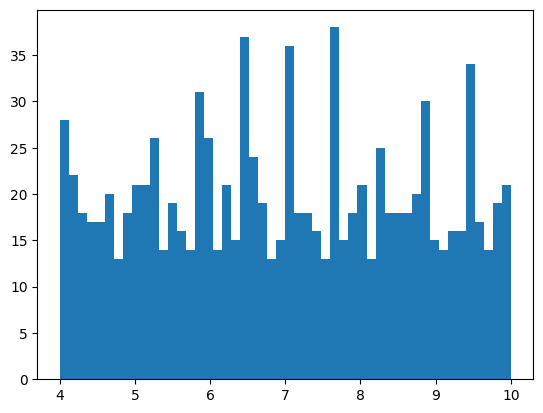

In [16]:
plt.hist(regression_dataset['Rating'], 50)
plt.show()

The rating distribution is essentially uniform, with no notable skewness. The case is different for gross income:

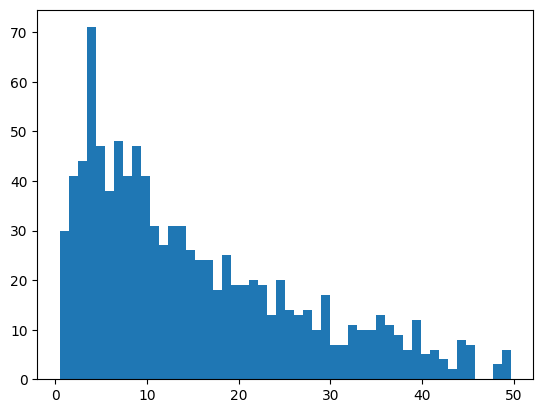

In [18]:
plt.hist(regression_dataset['gross income'], 50)
plt.show()

Here skewness is present, and the majority of orders seem to have a low gross income.
What, then, is the exact value of this skewness?

In [20]:
# code to compute the skewness of gross income
from scipy.stats import skew

# Convert the column to a numpy array
gross_income = regression_dataset['gross income'].to_numpy()

# Compute skewness
skewness_value = skew(gross_income)

print(f"Gross income skewness: {skewness_value:.4f}")

Gross income skewness: 0.8912


As expected from the plot, the skewness is positive, since the tail points to the right. This means most sales generate a low average profit, while a minority of sales generate a high profit. This minority is exactly what the tail represents.
Considering this data comes from a supermarket, the pattern is not anomalous: it's normal to have many purchases of small, inexpensive items (groceries) and few purchases of expensive items (could be appliances, cookware, other kitchen accessories).

## Preprocessing: encoding, scaling, and split

Categorical variables (`Branch`, `City`, `Customer type`, `Gender`, `Product line`, `Payment`) cannot be used directly by the algorithms and need to be transformed into numerical vectors. **Label Encoding** is applied to `Gender`, and **One-Hot Encoding** to the remaining ones.

In [23]:
# code to perform encoding of the categorical variables

# 1. Label Encoding for Gender
regression_dataset['Gender'] = regression_dataset['Gender'].astype('category').cat.codes

# 2. One-Hot Encoding for the other variables
cols_to_encode = ['Branch', 'City', 'Customer type', 'Product line', 'Payment']
regression_dataset = pd.get_dummies(regression_dataset, columns=cols_to_encode, drop_first=True)

print(regression_dataset.head())

   Gender  Unit price  Quantity  gross income  Rating  Branch_B  Branch_C  \
0       0       74.69         7       26.1415     9.1     False     False   
1       0       15.28         5        3.8200     9.6     False      True   
2       1       46.33         7       16.2155     7.4     False     False   
3       1       58.22         8       23.2880     8.4     False     False   
4       1       86.31         7       30.2085     5.3     False     False   

   City_Naypyitaw  City_Yangon  Customer type_Normal  \
0           False         True                 False   
1            True        False                  True   
2           False         True                  True   
3           False         True                 False   
4           False         True                  True   

   Product line_Fashion accessories  Product line_Food and beverages  \
0                             False                            False   
1                             False                     

`Unit price` and `gross income` have very different scales from one another; the latter also has a skewed distribution. Both columns are standardized with **StandardScaler** to prevent them from artificially dominating distance- or gradient-based models.

In [25]:
# code to standardize the "Unit price" and "gross income" columns
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Select columns to transform
cols_to_scale = ['Unit price', 'gross income']

# Transform
regression_dataset[cols_to_scale] = scaler.fit_transform(regression_dataset[cols_to_scale])

print(regression_dataset[cols_to_scale].head())

   Unit price  gross income
0    0.718160      0.919607
1   -1.525303     -0.987730
2   -0.352781      0.071446
3    0.096214      0.675780
4    1.156959      1.267125


The data is split into a **training set** (80%) and a **test set** (20%) before training. The split is randomized with `random_state=42` to ensure reproducibility of the results.

In [27]:
from sklearn.model_selection import train_test_split

# code to split the dataset into training set and test set

# 1. Define target variable (y) and features (X)

y = regression_dataset['Rating']
X = regression_dataset.drop('Rating', axis=1)

# 2. Perform an 80:20 split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)

# Check the shapes
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (800, 16)
Test set shape: (200, 16)


## Linear Regression

We start with the simplest model as a baseline reference.

In [29]:
# train the model using linear regression
from sklearn.linear_model import LinearRegression

# 1. Create the model
regressor = LinearRegression()

# 2. Train
regressor.fit(X_train, y_train)

# 3. Predict (the model is tested on what it learned, using the test set)
y_pred = regressor.predict(X_test)

The evaluation metrics are **MSE** and **MAE**, the main ones for regression problems.

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Compute the metrics
MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)

# Print the required metrics
print('MSE =', MSE, '\nMAE =', MAE)

MSE = 3.1101872910260715 
MAE = 1.5229214208487525


This means the model can be off by about 1.5 points when predicting the customer rating. This can be considered a decent result.

## Polynomial Regression

We try adding complexity by transforming the features into degree-2 polynomials, hypothesizing that relationships between variables aren't purely linear.

In [34]:
# train the model using polynomial regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Create the object to transform features into polynomial ones
poly_regressor = PolynomialFeatures(degree=2)

# 2. Transform the features (both train and test)
X_train_poly = poly_regressor.fit_transform(X_train)
X_test_poly = poly_regressor.transform(X_test)

# 3. Create and train the linear model on the new features
regressor = LinearRegression()
regressor.fit(X_train_poly, y_train)

# 4. Predict
y_pred_poly = regressor.predict(X_test_poly)

In [35]:
# 1. Compute the Mean Absolute Error (MAE)
MAE_poly = mean_absolute_error(y_test, y_pred_poly)

# 2. Compute the Mean Squared Error (MSE)
MSE_poly = mean_squared_error(y_test, y_pred_poly)

print(f"--- Polynomial Model Performance ---")
print('MSE_poly =', MSE_poly, '\nMAE_poly =', MAE_poly)

--- Polynomial Model Performance ---
MSE_poly = 3.452618857644124 
MAE_poly = 1.56929965306118


MSE and MAE values are larger than before, so the polynomial model does not perform better in this case. This is probably because the variables influencing the rating are categorical, and a polynomial model works better on continuous numerical variables.

## Random Forest

Finally, we test an ensemble model, more robust than the previous ones on data with heterogeneous features.

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Initialize the model (100 decision trees)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print(f"Random Forest MAE: {mean_absolute_error(y_test, y_pred_rf)}")
print(f"Random Forest MSE: {mean_squared_error(y_test, y_pred_rf)}")

Random Forest MAE: 1.6149949999999997
Random Forest MSE: 3.5733233749999993


Results are slightly worse than linear regression. To understand why, we analyze **feature importance**: there might be a column indirectly correlated with the rating calculation that's distorting the model.

<Axes: >

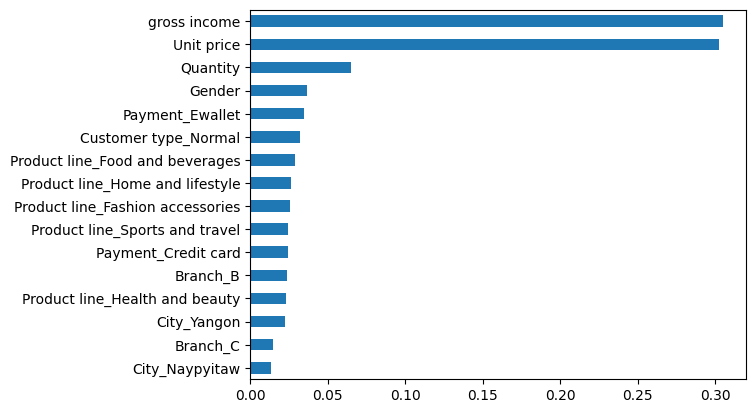

In [40]:
pd.Series(rf_model.feature_importances_, index=X.columns).sort_values().plot(kind='barh')

It seems likely that the rating was calculated from quantity and Unit Price, and is not a customer evaluation independent of the other fields in the dataset.

## Time series analysis

In the previous section, the temporal information was discarded because it wasn't useful for predicting the Rating. Here it is instead recovered to answer a different question: **can the trend of gross income over time be predicted?**

We build a subset of the original dataset containing only the `Date` and `gross income` columns.

In [43]:
# code to build a new dataset, starting from regression_raw_dataset, with only the "Date" and "gross income" columns
timeseries_dataset = regression_raw_dataset[['Date', 'gross income']].copy()

In [44]:
timeseries_dataset.head(100)

,Date,gross income
0,1/5/2019,26.1415
1,3/8/2019,3.8200
2,3/3/2019,16.2155
3,1/27/2019,23.2880
4,2/8/2019,30.2085
...,...,...
95,3/8/2019,4.8580
96,3/29/2019,43.9350
97,2/9/2019,3.7350
98,3/23/2019,7.9125


As a first approach, we test **linear regression** to check whether a linear trend exists in gross income as time progresses.

In [46]:
# Data preparation
from datetime import datetime

# Convert 'Date' to datetime format
timeseries_dataset['Date'] = pd.to_datetime(timeseries_dataset['Date'])

# Sort data by date (essential for time series)
timeseries_dataset = timeseries_dataset.sort_values('Date')

# Convert dates to ordinal numbers
# This allows the model to compute the slope with respect to days
X = timeseries_dataset['Date'].map(datetime.toordinal).values.reshape(-1, 1)
y = timeseries_dataset['gross income'].values


In [47]:
# train the time series model using linear regression

# Initialize and train the model
model = LinearRegression()
model.fit(X, y)

# Generate predictions (the regression line)
y_pred = model.predict(X)

print(f"Coefficient (Slope): {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

Coefficient (Slope): -0.010672696072520018
Intercept: 7882.26637752958


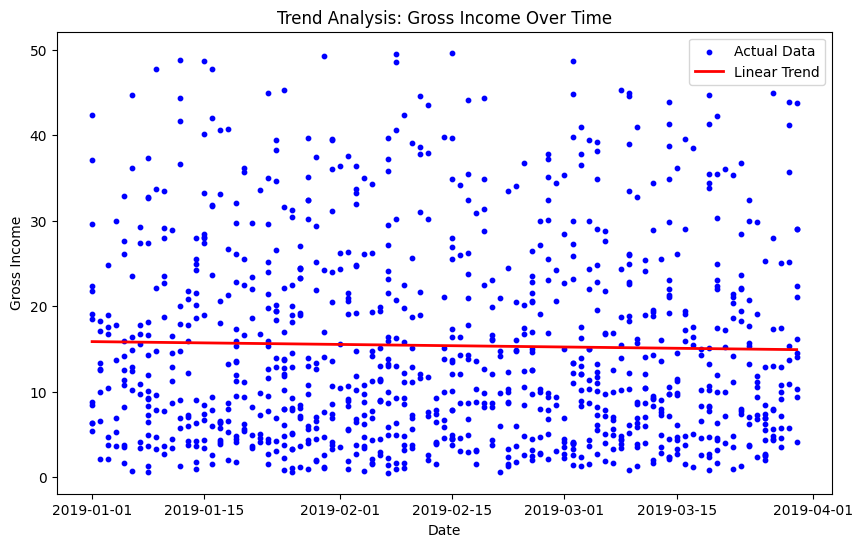

In [48]:
plt.figure(figsize=(10, 6))
plt.scatter(timeseries_dataset['Date'], y, color='blue', label='Actual Data', s=10)
plt.plot(timeseries_dataset['Date'], y_pred, color='red', linewidth=2, label='Linear Trend')
plt.xlabel('Date')
plt.ylabel('Gross Income')
plt.title('Trend Analysis: Gross Income Over Time')
plt.legend()
plt.show()

No clear linear trend emerges from the plot: gross income might have cyclical patterns related to the day of the week or the season, which a straight line cannot capture.

In [50]:
# Compute predictions on our dataset
y_pred = model.predict(X)

# Compute the metrics
MSE_ts = mean_squared_error(y, y_pred)
MAE_ts = mean_absolute_error(y, y_pred)

print('Time Series MSE =', MSE_ts, '\nTime Series MAE =', MAE_ts)

Time Series MSE = 136.8876806798879 
Time Series MAE = 9.615855455467681


In [51]:
# To get a sense of the results
mean_income = timeseries_dataset['gross income'].mean()
print(f"Mean gross income: {mean_income}")

Mean gross income: 15.379369


A MAE of 9.6 on an average income of 15.4 is very high: the model is off by a proportionally large margin. As expected, linear regression is not suited to this time series. The closeness between MAE and $\sqrt{MSE}$ indicates that errors are uniformly distributed across the dataset, with no dominant outliers.

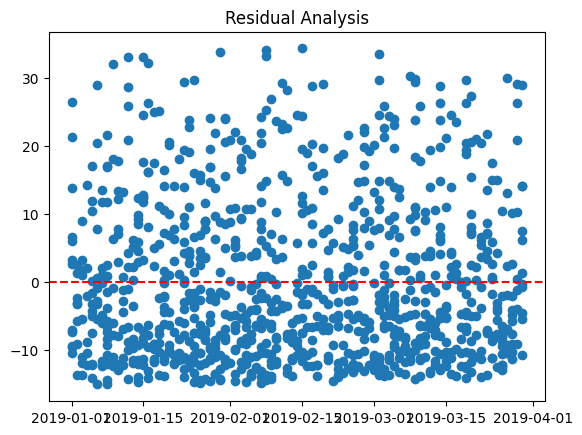

In [53]:
# residuals. If the errors follow a pattern, the model is too simple
residuals = y - y_pred
plt.scatter(timeseries_dataset['Date'], residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Analysis")
plt.show()

In [54]:
r2 = model.score(X, y)
print(f"R-squared: {r2:.4f}")

R-squared: 0.0005


R² is close to zero: the date does not explain the variance in gross income. Earnings depend on other factors, not on a temporal trend.

## Time series with XGBoost

We replace linear regression with XGBoost, a gradient-boosting ensemble model, to check whether a more powerful algorithm can find temporal patterns that linear regression fails to capture.

In [57]:
# Training and performance evaluation of the time series model with XGBoost
import xgboost as xgb

# Create temporal features
df = timeseries_dataset.copy()
df['day_of_week'] = df['Date'].dt.dayofweek
df['day_of_month'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Define X (features) and y (target)
X = df[['day_of_week', 'day_of_month', 'month', 'is_weekend']]
y = df['gross income']

# Split the data: important not to mix future with past
# Use shuffle=False to preserve chronological order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [58]:
# Initialize the model
# n_estimators: number of trees, max_depth: tree depth
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, objective='reg:squarederror')

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

In [59]:
# comparison with the previously obtained metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MAE_xgb = mean_absolute_error(y_test, y_pred_xgb)
MSE_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"--- XGBoost Results ---")
print(f"MAE_xgb: {MAE_xgb:.2f}")
print(f"MSE_xgb: {MSE_xgb:.2f}")
print(f"R-squared: {r2_xgb:.4f}")

--- XGBoost Results ---
MAE_xgb: 9.55
MSE_xgb: 138.00
R-squared: -0.0641


XGBoost also produces a negative R²: the model performs worse than simply predicting the mean. MAE and MSE remain similar to those obtained with linear regression, confirming that gross income shows no temporal dependence. The issue isn't the model — it's the absence of structure in the data.

We dig deeper with a **correlation heatmap** to identify which variables in the original dataset are actually related to gross income.

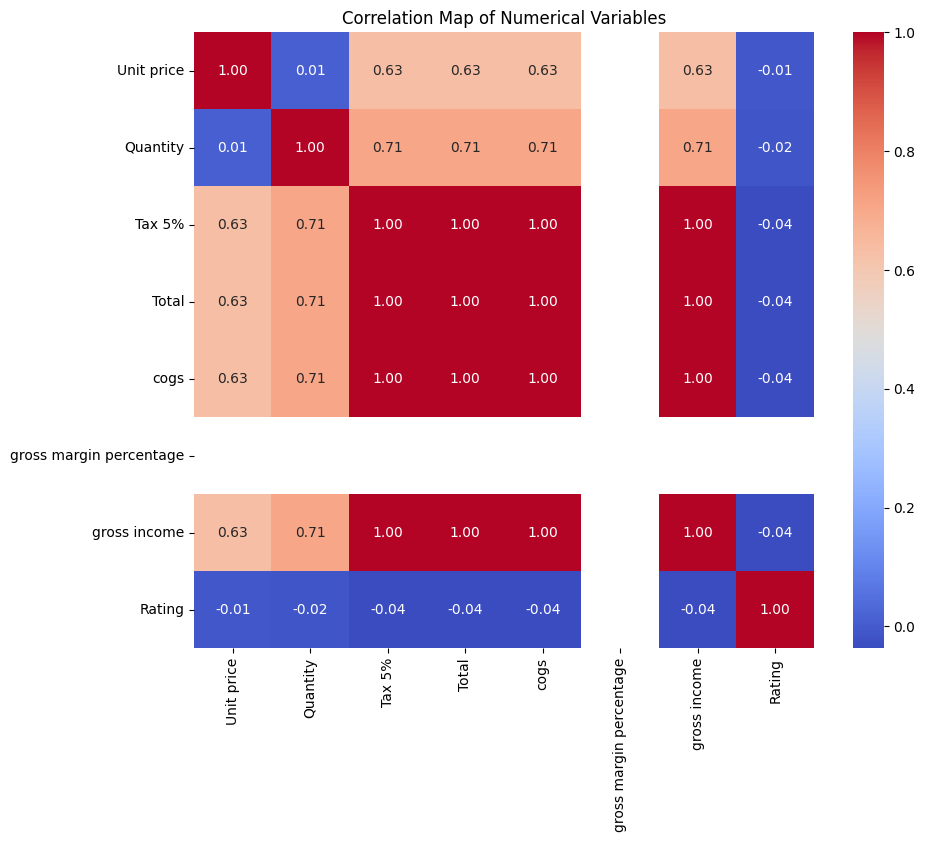

In [62]:
import seaborn as sns
# Select only numeric columns (int and float)
numeric_df = regression_raw_dataset.select_dtypes(include=['float64', 'int64'])

# Compute correlation
plt.figure(figsize=(10, 8))
correlation_matrix = numeric_df.corr()

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Map of Numerical Variables")
plt.show()


`Unit price` and `Quantity` show a strong correlation with gross income. We build an XGBoost model using these variables — plus the categorical `Product line` and `City` — to check whether the relationship is genuinely predictive.

In [64]:
# 1. Prepare the dataset with the strong variables + categorical variables
# One-Hot Encoding to convert categorical columns into numerical columns (0/1)
features = ['Unit price', 'Quantity', 'Product line', 'City']
X = pd.get_dummies(regression_raw_dataset[features], drop_first=True)
y = regression_raw_dataset['gross income']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train with XGBoost
final_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6)
final_model.fit(X_train, y_train)

# 4. Evaluation
y_pred = final_model.predict(X_test)
print(f"New R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"New MAE: {mean_absolute_error(y_test, y_pred):.2f}")

New R-squared: 0.9990
New MAE: 0.27


Such a high R² reveals that gross income in this dataset **is not an observed quantity** but the result of an arithmetic calculation:

$$Gross\ Income = (Unit\ Price \times Quantity) \times \text{Profit Margin}$$

No model is needed to predict it: the formula alone is enough. A more useful target variable in a real-world context would be **quantity sold**, which reflects customer behavior and can guide restocking decisions.

In [66]:
# Rebuild the 'df' DataFrame starting from the original dataset
# Include both the feature columns and Date to build the time features
cols_to_use = ['Date', 'Quantity', 'Product line', 'City', 'Customer type']
df = regression_raw_dataset[cols_to_use].copy()

# 2. Rebuild the temporal features
df['Date'] = pd.to_datetime(df['Date'])
df['day_of_week'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Feature selection: Time + Categories
features_qty = ['day_of_week', 'month', 'is_weekend', 'Product line', 'City', 'Customer type']

# Convert categories to numbers (One-Hot Encoding)
X_qty = pd.get_dummies(df[features_qty], drop_first=True)
y_qty = df['Quantity']

# Split the data
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(X_qty, y_qty, test_size=0.2, random_state=42)

# Train with XGBoost
model_qty = xgb.XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=5)
model_qty.fit(X_train_q, y_train_q)

# Predictions and metrics
y_pred_q = model_qty.predict(X_test_q)

print(f"R-squared for Quantity: {r2_score(y_test_q, y_pred_q):.4f}")
print(f"MAE for Quantity: {mean_absolute_error(y_test_q, y_pred_q):.2f}")

R-squared for Quantity: -0.1588
MAE for Quantity: 2.52


Negative R²: city, day, and product category do not allow us to predict how many items will be sold. The quantities purchased by customers show no dependence on these variables.

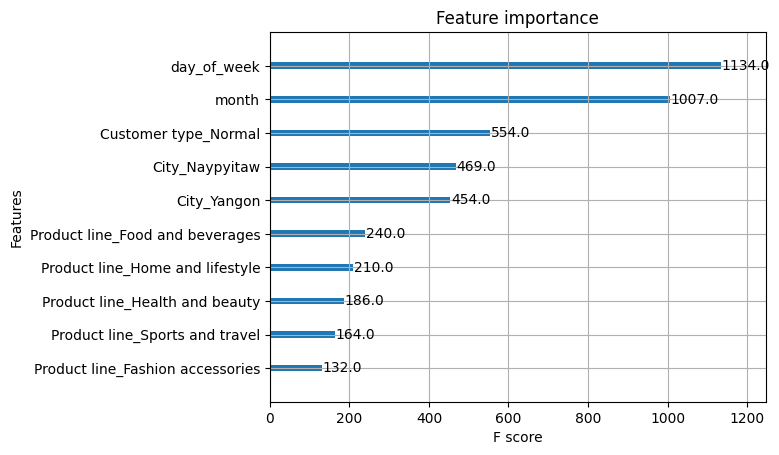

In [68]:
xgb.plot_importance(model_qty)
plt.show()

XGBoost identifies a dependence on day of the week and month, but the model still fails on the test set. We check whether the averages by day of the week are actually different.

In [70]:
# Check whether the average actually changes by day of the week
print(df.groupby('day_of_week')['Quantity'].mean())

# And by month
print(df.groupby('month')['Quantity'].mean())

day_of_week
0    5.104000
1    5.455696
2    5.594406
3    5.471014
4    5.453237
5    5.603659
6    5.849624
Name: Quantity, dtype: float64
month
1    5.582386
2    5.458746
3    5.481159
Name: Quantity, dtype: float64


Daily averages range from 5.1 (Monday) to 5.8 (Sunday) — a real but minimal difference. Within any single day, values still range from 1 to 10: the signal is too weak to build a reliable model for individual customers. We change perspective and try to predict the store's **total daily sales** instead.

In [72]:
cols_to_use = ['Date', 'Quantity', 'gross income']
df = regression_raw_dataset[cols_to_use].copy()
df['Date'] = pd.to_datetime(df['Date'])

# Build the daily dataset
daily_df = df.groupby('Date').agg({
    'Quantity': 'sum',
    'gross income': 'sum'
}).reset_index()

# Temporal features on the new dataset
daily_df['day_of_week'] = daily_df['Date'].dt.dayofweek
daily_df['month'] = daily_df['Date'].dt.month
daily_df['day'] = daily_df['Date'].dt.day

print(f"The new dataset has {len(daily_df)} days.")

The new dataset has 89 days.


The dataset spans about 90 days: after the split, the training set has about 70 days, a very small number for training a time series model.

In [74]:
# Features and target
X_daily = daily_df[['day_of_week', 'month', 'day']]
y_daily = daily_df['Quantity']

# Split (preserving chronological order)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_daily, y_daily, test_size=0.2, shuffle=False)

# XGBoost
daily_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05)
daily_model.fit(X_train_d, y_train_d)

# Predictions and R-squared
y_pred_d = daily_model.predict(X_test_d)
print(f"Daily R-squared: {r2_score(y_test_d, y_pred_d):.4f}")

Daily R-squared: -0.7861


R² is still negative. We plot daily sales to check whether there's a visual pattern the model might be failing to capture.

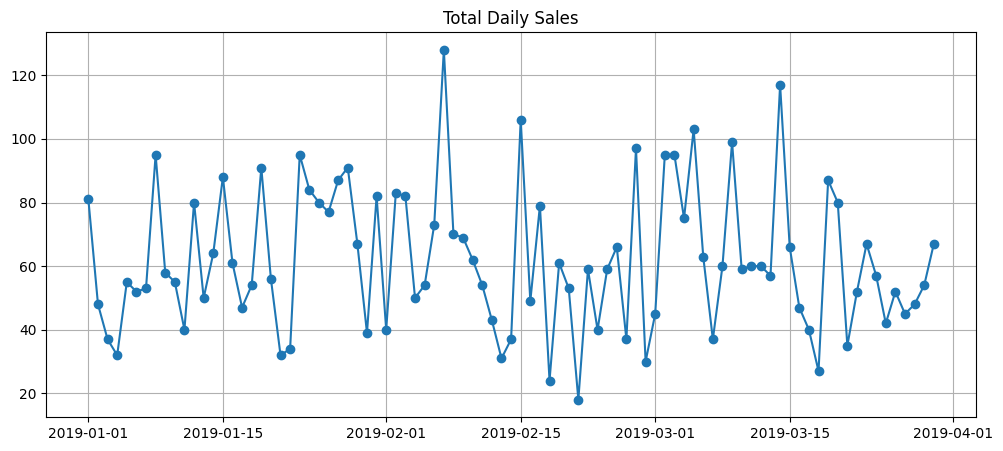

In [76]:
plt.figure(figsize=(12, 5))
plt.plot(daily_df['Date'], daily_df['Quantity'], marker='o')
plt.title("Total Daily Sales")
plt.grid(True)
plt.show()

There seems to be no dependence on the date, just a lot of fluctuation. We can conclude that:
- there's no need for different stock levels between Monday and Sunday;

- no clear monthly seasonality is observed;

- the store's performance depends on factors outside the dataset (weather, promotions, competition).

As a last attempt, we add a **3-day rolling average** as a feature. The idea is to give the model context on the recent trend: whether sales are growing or declining, this information might improve the prediction.

In [79]:
# Create lag features
daily_df['yesterday'] = daily_df['Quantity'].shift(1)
daily_df['rolling_3_day_avg'] = daily_df['Quantity'].shift(1).rolling(window=3).mean()

# Remove the first days, which will have NaN values (since there's no 'yesterday' for them)
df_memory = daily_df.dropna()

# Define the features, including the historical ones
X_mem = df_memory[['day_of_week', 'month', 'day', 'yesterday', 'rolling_3_day_avg']]
y_mem = df_memory['Quantity']

# Chronological split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mem, y_mem, test_size=0.2, shuffle=False)

# Training
model_mem = xgb.XGBRegressor(n_estimators=50, learning_rate=0.05)
model_mem.fit(X_train_m, y_train_m)

# Results
y_pred_m = model_mem.predict(X_test_m)
print(f"R-squared with memory features: {r2_score(y_test_m, y_pred_m):.4f}")

R-squared with memory features: -0.2347


R² is still negative. Sales volumes show no temporal dependence detectable with the available data: fluctuations appear to be dominated by external variables not captured in the dataset.

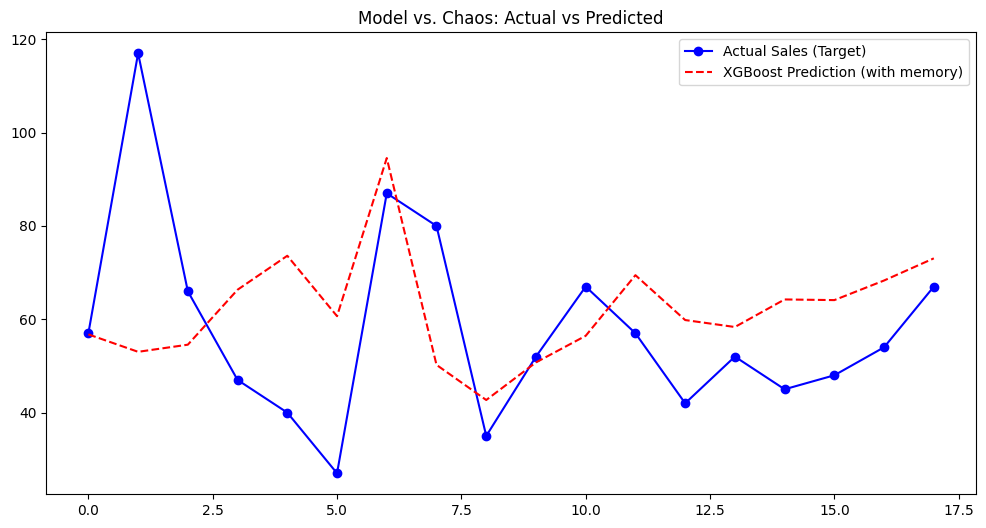

In [81]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_m.values, label='Actual Sales (Target)', color='blue', marker='o')
plt.plot(y_pred_m, label='XGBoost Prediction (with memory)', color='red', linestyle='--')
plt.title("Model vs. Chaos: Actual vs Predicted")
plt.legend()
plt.show()

## Gross income analysis by product category

We conclude the analysis of the supermarket_sales dataset by checking whether certain product categories generate significantly higher profits than others.

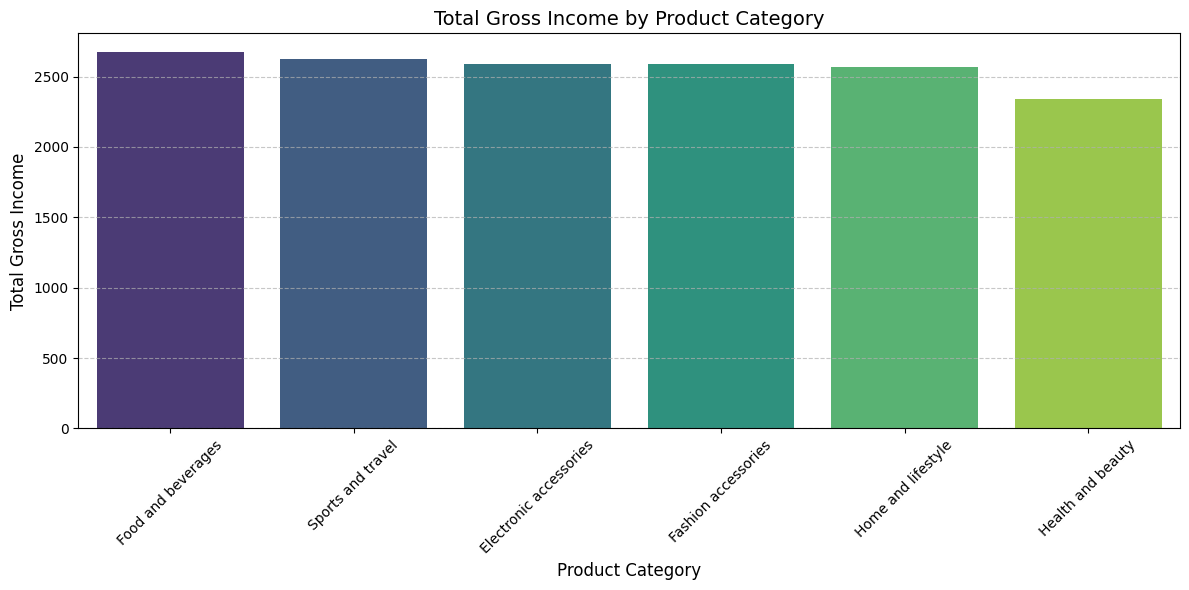

             Product line  gross income
0      Food and beverages     2673.5640
1       Sports and travel     2624.8965
2  Electronic accessories     2587.5015
3     Fashion accessories     2585.9950
4      Home and lifestyle     2564.8530
5       Health and beauty     2342.5590


In [83]:
# 1. Compute the ranking
top_products = regression_raw_dataset.groupby('Product line')['gross income'].sum().sort_values(ascending=False).reset_index()

# 2. Vertical bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_products,
    x='Product line',
    y='gross income',
    hue='Product line',
    palette='viridis',
    legend=False
)

# 3. Aesthetic formatting
plt.title('Total Gross Income by Product Category', fontsize=14)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Gross Income', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(top_products)

The distribution of gross income across categories is fairly balanced. Food & Beverage is slightly ahead, consistent with the nature of a supermarket where grocery purchases are the most frequent.

---
# Part 2 — Apple Quality

The `apple_quality` dataset describes the physical and organoleptic characteristics (size, weight, sweetness, crunchiness, juiciness, ripeness, acidity) of 4,000 apples, each labeled as **good** or **bad**. The goal is to build models capable of automatically classifying apple quality, with potential applications in selecting incoming produce at a retail point.

Both **supervised** (Logistic Regression, Decision Tree) and **unsupervised** (K-Means Clustering) approaches are explored.


## Logistic Regression

We start with the baseline linear classification model.

In [87]:
# code to import the apple_quality dataset
classification_dataset = pd.read_csv('apple_quality.csv')

In [88]:
# code to print the first 50 rows
classification_dataset.head(50)

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good
5,5.0,-3.425400,-1.409082,-1.913511,-0.555775,-3.853071,1.914616,-2.981523169,bad
6,6.0,1.331606,1.635956,0.875974,-1.677798,3.106344,-1.847417,2.414170509,good
7,7.0,-1.995462,-0.428958,1.530644,-0.742972,0.158834,0.974438,-1.470125066,good
8,8.0,-3.867632,-3.734514,0.986429,-1.207655,2.292873,4.080921,-4.871904758,bad
9,9.0,-0.727983,-0.442820,-4.092223,0.597513,0.393714,1.620857,2.185607723,bad


In [89]:
# code to display the main metadata of the apple_quality dataset
classification_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   object 
 8   Quality      4000 non-null   object 
dtypes: float64(7), object(2)
memory usage: 281.4+ KB


The dataset is already clean and almost entirely numerical. The only exception is the `Quality` label (good/bad), which is encoded into binary values (1/0). The `A_id` column (an identifier with no predictive value) is then removed, and **StandardScaler** is applied before an 80/20 split stratified on the label.

In [91]:
# code to encode the "Quality" label

classification_dataset['Quality'] = classification_dataset['Quality'].map({'good': 1, 'bad': 0})

In [92]:
# code to split the apple_quality dataset into train/test
from sklearn.preprocessing import StandardScaler

# Remove the last row if it contains null values or text in the ID column
classification_dataset = classification_dataset.dropna()

# Remove Quality (target) and A_id from the features
X = classification_dataset.drop(['Quality', 'A_id'], axis=1, errors='ignore')
y = classification_dataset['Quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Use StandardScaler to bring everything to the same mean (0) and standard deviation (1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Total samples: {len(X)}")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Total samples: 4000
Training set: 3200 samples
Test set: 800 samples


In [93]:
# code to train the model using logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Create the model
logistic_regressor = LogisticRegression(max_iter=1000)

# 2. Train
logistic_regressor.fit(X_train, y_train)

# 3. Predict
y_pred = logistic_regressor.predict(X_test)

As the main metric, we use the **F1 score**, which balances precision and recall and is more informative than accuracy on datasets with potentially imbalanced classes.

In [95]:
from sklearn.metrics import classification_report

y_predict_test = logistic_regressor.predict(X_test)

print(classification_report(y_test, y_predict_test))

              precision    recall  f1-score   support

         0.0       0.76      0.71      0.74       399
         1.0       0.73      0.77      0.75       401

    accuracy                           0.74       800
   macro avg       0.74      0.74      0.74       800
weighted avg       0.74      0.74      0.74       800



F1 is very similar for 0.0 and 1.0, meaning the classes are balanced. The 74% accuracy indicates the model has captured the apple split reasonably well, but there's still a 26% error rate due to non-linear relationships between the variables. If the apples were plotted on a graph, they likely cannot be separated by a straight line without some errors.

We analyze the **confusion matrix** to understand where the model makes mistakes: how many bad apples are misclassified as good (false positives), and how many good apples get discarded (false negatives).

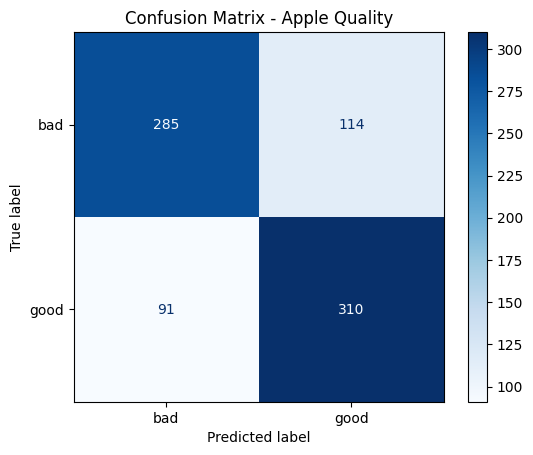

In [98]:
# code for the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the confusion matrix
cm = confusion_matrix(y_test, y_predict_test)

# 2. Plot it
# Use 0 for 'bad' and 1 for 'good'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['bad', 'good'])

disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Apple Quality')
plt.show()

Out of 800 samples, the model correctly classified 595, a sufficient but not optimal result.

False positives: 114 apples were incorrectly classified as good. This can be a problem for a seller, who ends up selling a subpar product in 114 cases.
Reducing this number would help improve profits and customer ratings.

False negatives: this leads to waste — 91 good apples were classified as bad and end up discarded. Minimizing this number would reduce food waste.

## Decision Tree

We try a Decision Tree, a non-linear model that might capture the relationships between the apples' physical characteristics better.

In [101]:
# train the model using a decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Create the model
decision_tree = DecisionTreeClassifier(max_depth=5, random_state=42)

# 2. Train
decision_tree.fit(X_train, y_train)

# 3. Predict
y_pred_tree = decision_tree.predict(X_test)

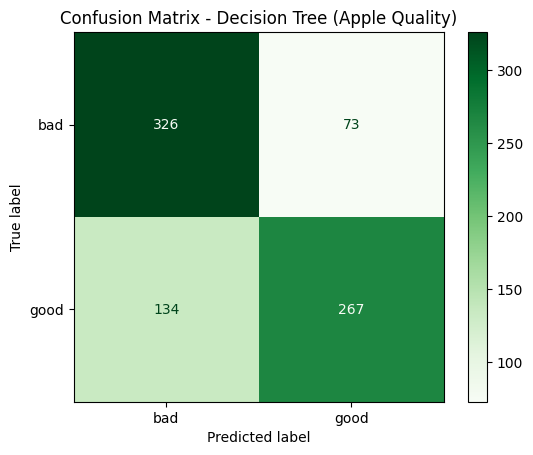

              precision    recall  f1-score   support

         0.0       0.71      0.82      0.76       399
         1.0       0.79      0.67      0.72       401

    accuracy                           0.74       800
   macro avg       0.75      0.74      0.74       800
weighted avg       0.75      0.74      0.74       800



In [102]:
# decision tree confusion matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['bad', 'good'])
disp.plot(cmap=plt.cm.Greens) # Using green to distinguish from previous tests
plt.title('Confusion Matrix - Decision Tree (Apple Quality)')
plt.show()

# Print the report to see Precision and Recall
print(classification_report(y_test, y_pred_tree))


First, we notice that accuracy stayed the same despite the model change.

Compared to the previous one, this model is better at identifying bad apples, correctly identifying 82% of them, i.e. 329 out of 399, as also shown by the recall value of 0.82.
False positives are much lower — 73, compared to 114 before — so fewer bad apples are incorrectly classified as good.

On good apples, however, performance is worse (recall 0.67). This time, as many as 134 apples were incorrectly classified as bad, resulting in more waste.

### Feature importance

We analyze the tree's **feature importance**: it indicates how much each characteristic (size, weight, sweetness, etc.) contributed to reducing impurity in the nodes during construction.

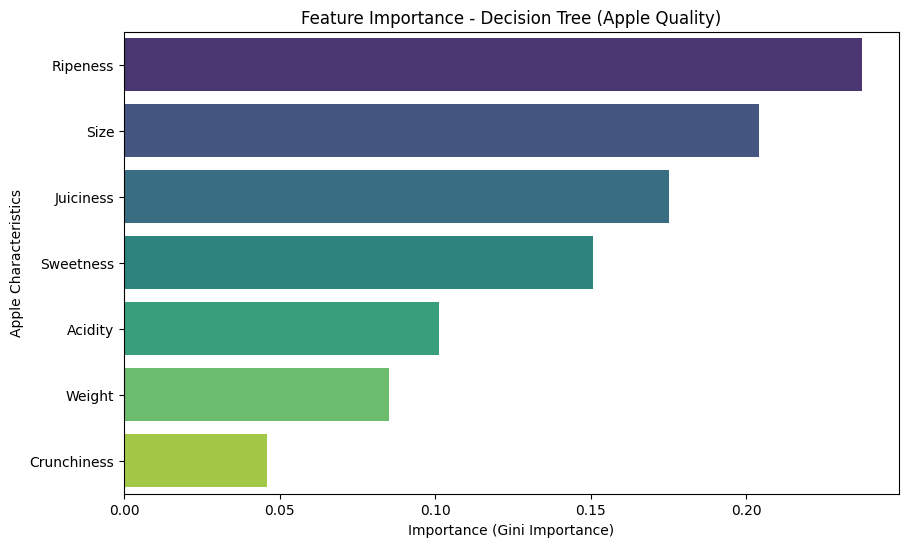

In [105]:
# code for feature importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X_classification_features = classification_dataset.drop(['Quality', 'A_id'], axis=1, errors='ignore')

# 1. Extract from the model
importances = decision_tree.feature_importances_
feature_names = X_classification_features.columns

# 2. Create a DataFrame for easier visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 3. Sort the DataFrame from most to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title('Feature Importance - Decision Tree (Apple Quality)')
plt.xlabel('Importance (Gini Importance)')
plt.ylabel('Apple Characteristics')
plt.show()

This chart shows how much each field helps the model distinguish a good apple from a bad one. The biggest contributors are ripeness and apple size, while crunchiness and weight matter relatively little.

## K-Means Clustering

We move on to unsupervised clustering. The `Quality` label is removed: the goal is to check whether apples naturally group into clusters consistent with quality, without the model knowing it beforehand.

In [108]:
clustering_dataset = classification_dataset.drop(columns=['Quality'])

As a first attempt, **k=2** is set, hypothesizing that the data splits neatly into two groups corresponding to the two classes.

In [110]:
# code to train the model with K-Means Clustering
from sklearn.cluster import KMeans

# 1. Initialize the model with 2 clusters
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)

# 2. Train and assign clusters
clusters = kmeans.fit_predict(X)

# 3. Add the results to the dataset for analysis
X_clustered = X.copy()
X_clustered['Cluster'] = clusters

print(X_clustered['Cluster'].value_counts())

Cluster
0    2329
1    1671
Name: count, dtype: int64


To test the model, an apple with known characteristics is classified, and we check which cluster it is assigned to.

In [112]:
import pandas as pd

# 1. Data for the new apple
new_apple_data = [[0.5, -1.2, 2.3, -0.5, 1.8, 0.4, -0.2]]

# 2. DataFrame with the column names of X
new_apple_df = pd.DataFrame(new_apple_data, columns=X.columns)

# 3. Predict the cluster
assigned_cluster = kmeans.predict(new_apple_df)

print(f"The new apple was assigned to Cluster: {assigned_cluster[0]}")

The new apple was assigned to Cluster: 1


In [113]:
# Create a table to see how Cluster and Quality overlap
df_analysis = pd.DataFrame({'Cluster': clusters, 'Quality': classification_dataset['Quality']})
print(pd.crosstab(df_analysis['Cluster'], df_analysis['Quality']))

Quality   0.0   1.0
Cluster            
0        1314  1015
1         682   989


With k=2, the clusters do not cleanly correspond to the two categories: both contain a similar mix of good and bad apples. The test apple is assigned to the cluster with a slight prevalence of good apples, but the separation is not reliable.

We try **k=3** to check whether an intermediate cluster improves the separation.

In [116]:
# Initialize with 3 clusters
kmeans_3 = KMeans(n_clusters=3, n_init=10, random_state=42)

# Train
clusters_3 = kmeans_3.fit_predict(X)

# Add the new clusters to the DataFrame for analysis
X_clustered_3 = X.copy()
X_clustered_3['Cluster_3'] = clusters_3

print("Distribution of samples across the 3 clusters:")
print(X_clustered_3['Cluster_3'].value_counts())

Distribution of samples across the 3 clusters:
Cluster_3
0    1547
1    1254
2    1199
Name: count, dtype: int64


In [117]:
# Predict with the new 3-cluster model
assigned_cluster_3 = kmeans_3.predict(new_apple_df)

print(f"With k=3, the new apple belongs to Cluster: {assigned_cluster_3[0]}")

With k=3, the new apple belongs to Cluster: 2


In [118]:
# again, cross-check with the Quality column

df_analysis_3 = pd.DataFrame({'Cluster_3': clusters_3, 'Quality': classification_dataset['Quality']})
print(pd.crosstab(df_analysis_3['Cluster_3'], df_analysis_3['Quality']))

Quality     0.0  1.0
Cluster_3           
0          1036  511
1           493  761
2           467  732


With k=3, the separation improves: one cluster consists mostly of bad apples, the other two mostly of good apples. The test apple is classified as probably good. We now look for the optimal number of clusters using the elbow method.

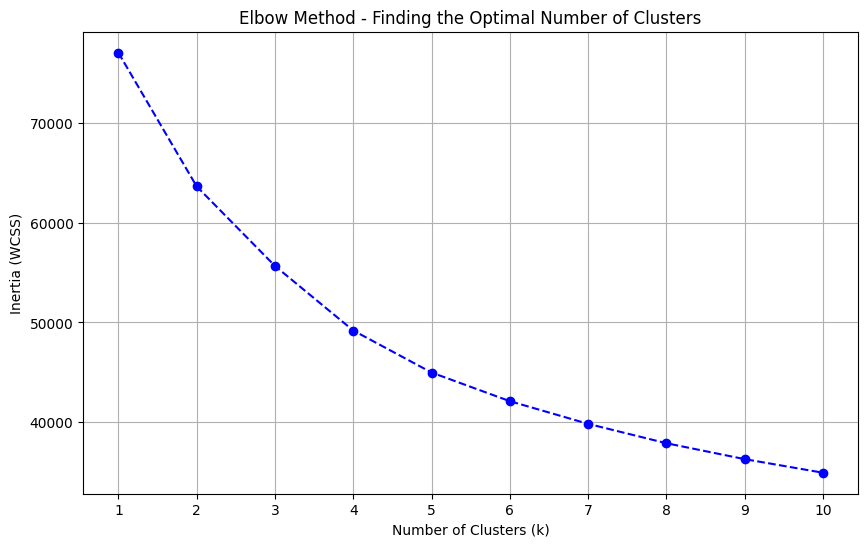

In [120]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Prepare the data (numeric only, no NaN)
# If columns like 'Cluster_3' were added earlier, they need to be removed for this test
X_numeric = X.select_dtypes(include=[np.number])

inertia = []
K_range = range(1, 11) # Test from 1 to 10 clusters

# 2. Loop to compute inertia
for k in K_range:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(X_numeric)
    inertia.append(model.inertia_)

# 3. Plot
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method - Finding the Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

The plot shows a clear change in slope between k=2 and k=3: adding more clusters does not bring a proportional gain in reducing inertia. **k=3** is the optimal number of clusters for this dataset.

---
# Final analysis and considerations

The analysis was carried out in two distinct parts, each dedicated to a dataset and a family of Machine Learning problems.

## Evaluation metrics

The following metrics were used to measure model effectiveness:

- $MSE\ (Mean\ Squared\ Error)$: average of the squared errors; heavily penalizes outliers.

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- $MAE\ (Mean\ Absolute\ Error)$: average of the absolute differences between actual and predicted values; gives an immediate sense of the model's average error.

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

- $R^2$: proportion of variance explained by the model. Ranges from 0 to 1 (negative values indicate a model worse than simply predicting the mean).

---

## Part 1 — Supermarket Sales

### Regression on Rating

Three models were compared to predict transaction Rating:

- **Linear Regression** (MSE: 3.11, MAE: 1.52): the best trade-off; the model is off by about 1.5 points on average.
- **Polynomial Regression** (MSE: 3.45, MAE: 1.57): no improvement, suggesting the relationship between features isn't intrinsically non-linear.
- **Random Forest** (MSE: 3.57, MAE: 1.61): slightly lower performance, likely due to the mostly categorical nature of the variables or the lack of tuning.

### Time series analysis

The temporal analysis of gross income produced negative results with both Linear Regression and XGBoost (negative or near-zero R²). The absence of clear seasonality or trend suggests that sales volume depends on external variables not present in the dataset (weather, promotions, competition). The gross income analysis by product category, on the other hand, showed a balanced distribution across departments, with Food and Beverage slightly ahead.

---

## Part 2 — Apple Quality

### Supervised classification

- **Logistic Regression** (accuracy: 74%): acceptable results. The model separates the two classes reasonably well, but the 26% error reflects the non-linearity of the data.
- **Decision Tree** (accuracy: 74%): same overall accuracy, but a different error distribution. The model is more effective at identifying bad apples (recall 0.82 on the "bad" class), reducing false positives from 114 to 73 compared to Logistic Regression. Trade-off: more false negatives (134 good apples discarded).

### Unsupervised clustering

K-Means Clustering confirmed that the data does not cleanly separate into 2 quality-homogeneous clusters. With k=3, the split is cleaner, suggesting the existence of an intermediate category of apples with mixed characteristics.
